In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np

# Set the path to the CSV file in the dataset
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "blastchar/telco-customer-churn",
    file_path,
)

# Convert to numeric, set errors='coerce' to turn invalid strings into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

median_value = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_value)

# Now safely apply log only to positive values
df['logTotalCharges'] = np.where(df['TotalCharges'] > 0, np.log(df['TotalCharges']), np.nan)
df['logMonthlyCharges'] = np.where(df['MonthlyCharges'] > 0, np.log(df['MonthlyCharges']), np.nan)

df_new = df.copy()

display(df)

<ipython-input-1-2b6841d8fe69>:12: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,logTotalCharges,logMonthlyCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,3.396185,3.396185
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,7.544068,4.042174
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4.683519,3.986202
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,7.517928,3.744787
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,5.021575,4.258446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,7.596141,4.440296
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,8.904209,4.636669
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,5.847739,3.387774
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,5.725544,4.309456


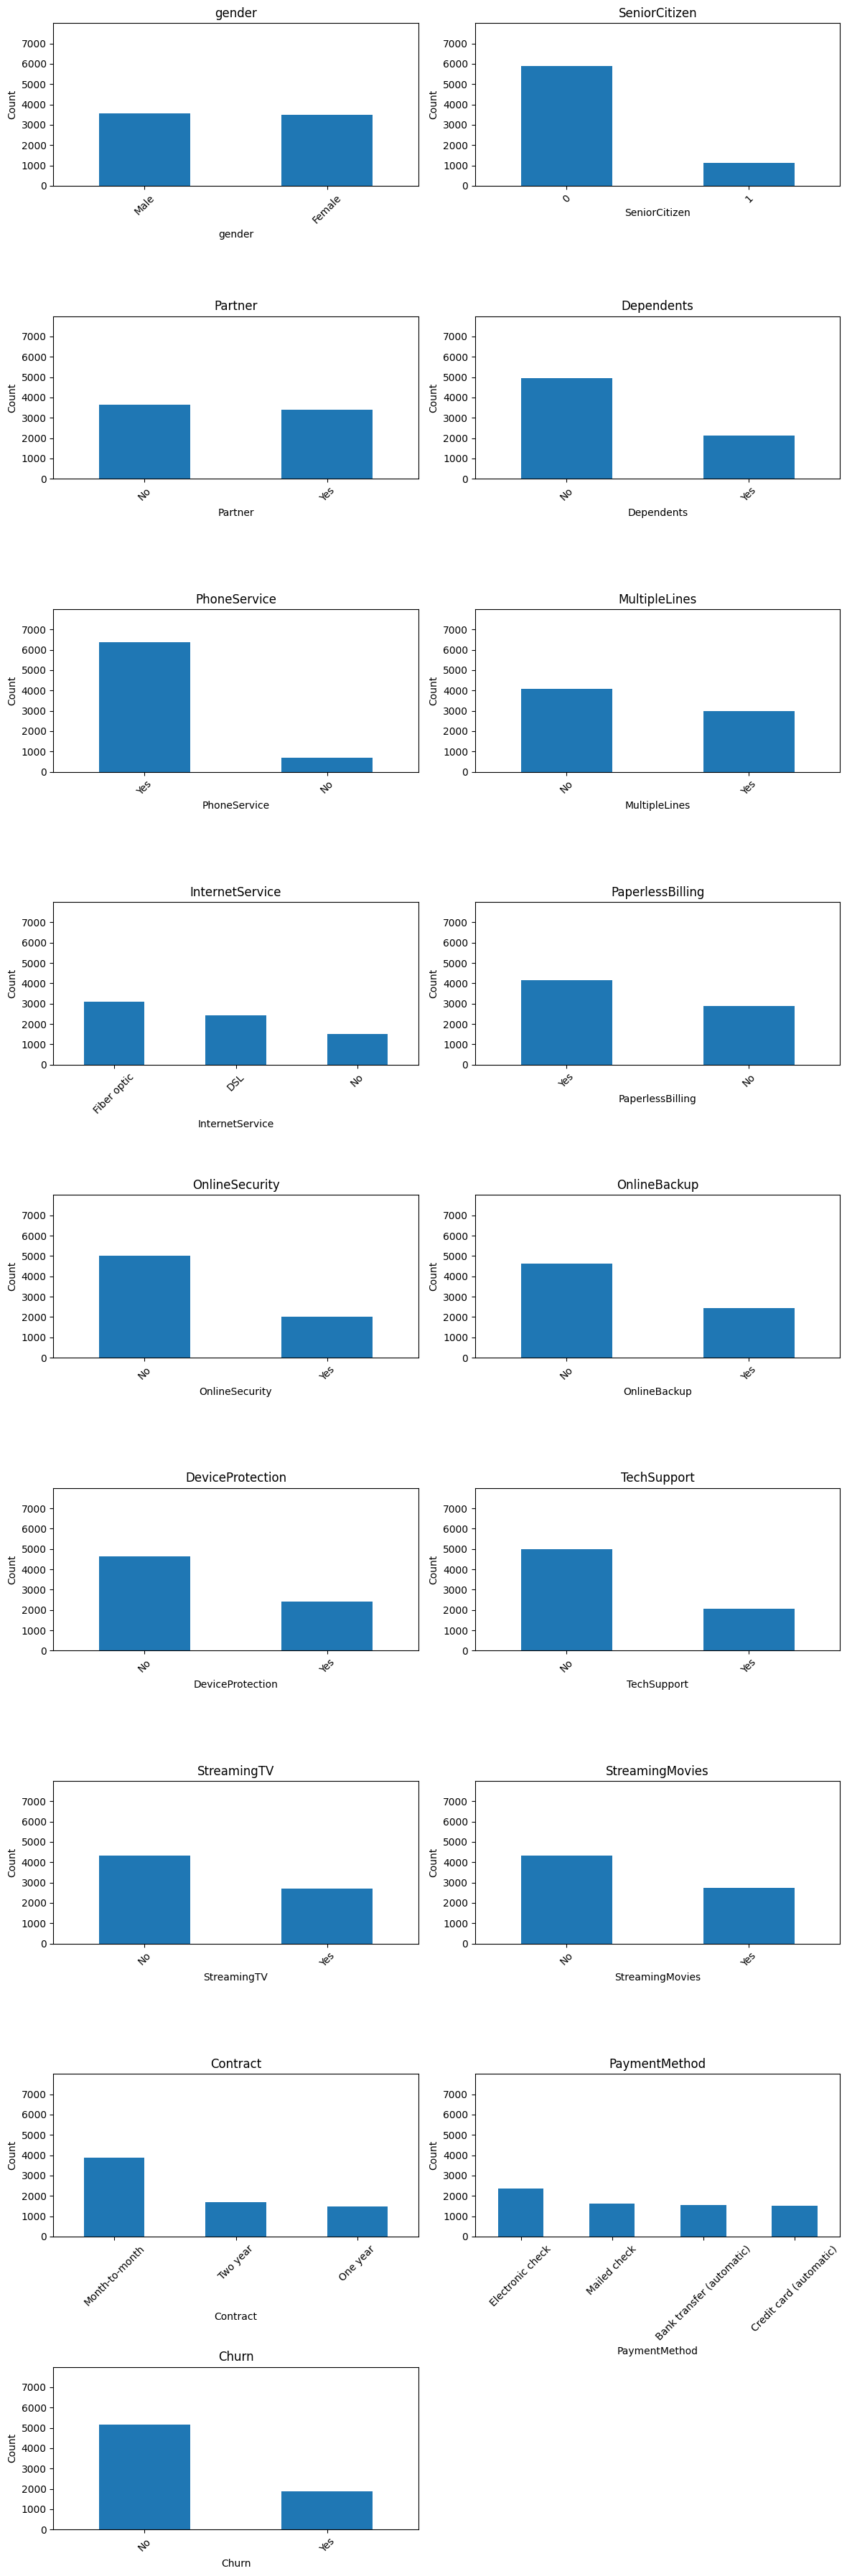

In [ ]:
import matplotlib.pyplot as plt

# Clean the data
df_new['MultipleLines'] = df_new['MultipleLines'].replace('No phone service', 'No')
columns_to_clean = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df_new[columns_to_clean] = df_new[columns_to_clean].replace('No internet service', 'No')

# Specify columns to plot
columns_to_plot = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines','InternetService','PaperlessBilling', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies','Contract','PaymentMethod','Churn'
]

# Y-axis ticks to use
y_ticks = list(range(0, 8000, 1000))

# Subplot layout
n = len(columns_to_plot)
n_cols = 2
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Plot each column
for i, col in enumerate(columns_to_plot):
    counts = df_new[col].value_counts()
    counts.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, 8000)
    axes[i].set_yticks(y_ticks)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

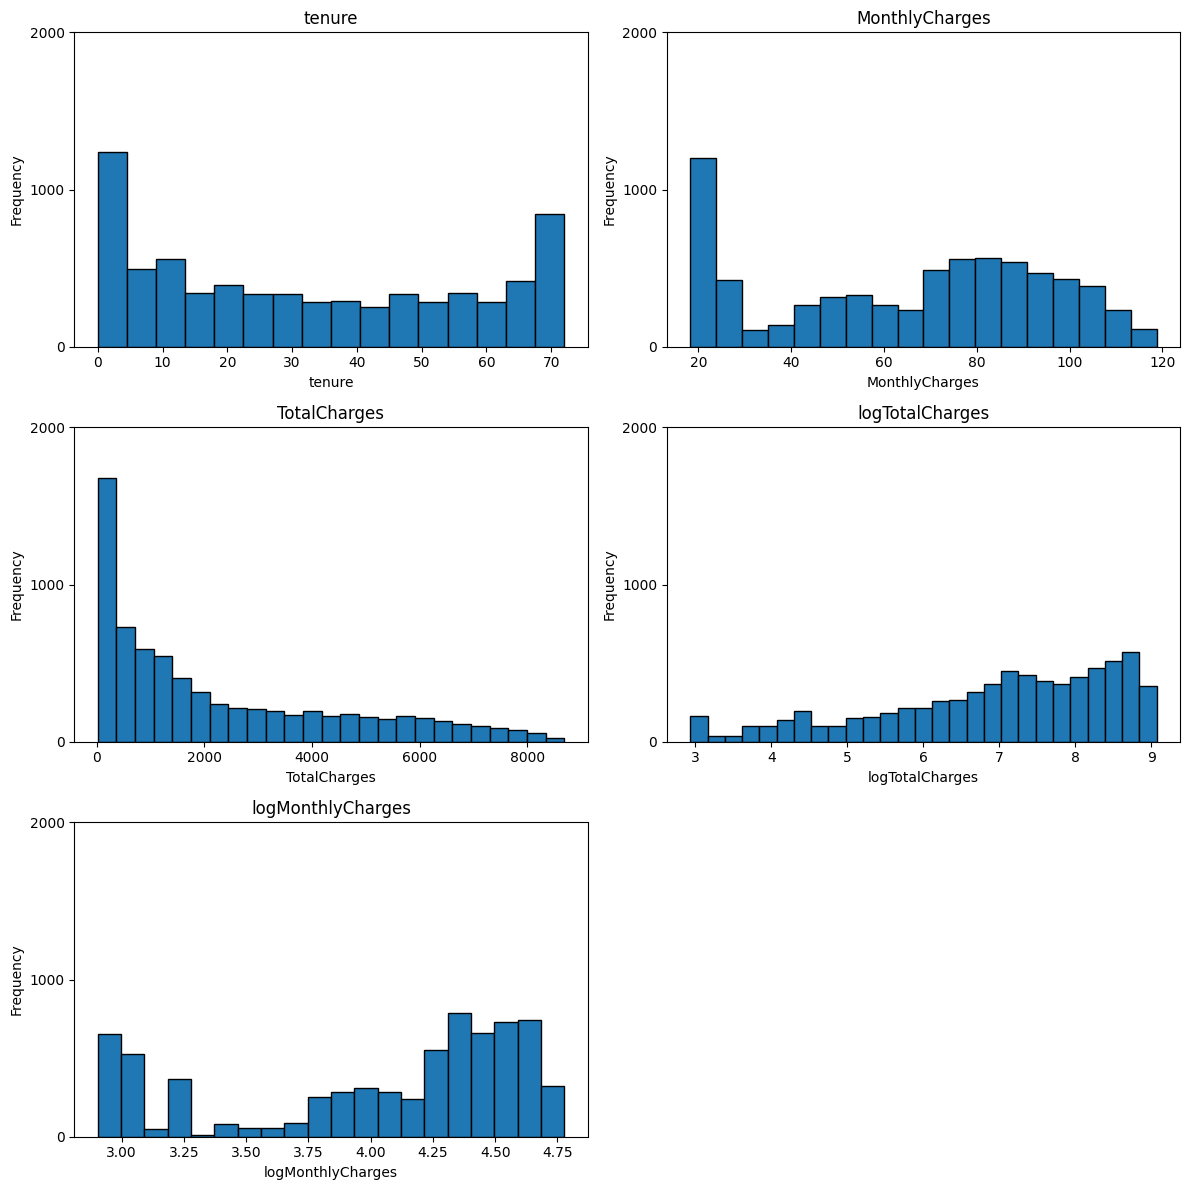

In [ ]:
import matplotlib.pyplot as plt

# Specify numeric columns to plot as histograms
additional_columns = ['tenure', 'MonthlyCharges', 'TotalCharges','logTotalCharges','logMonthlyCharges']

# Subplot layout
n = len(additional_columns)
n_cols = 2
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Plot each numeric column using histogram
for i, col in enumerate(additional_columns):
    df_new[col] = pd.to_numeric(df_new[col], errors='coerce')  # ensure numeric
    axes[i].hist(df_new[col].dropna(), bins='auto', edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_yticks(range(0, 3000, 1000))

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
unique_values = {col: df[col].unique() for col in df.columns}

# Print unique values for each column
for col, values in unique_values.items():
    print(f"{col}: {values}\n")

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender: ['Female' 'Male']

SeniorCitizen: [0 1]

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank tra

In [ ]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

In [ ]:
columns_to_clean = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df[columns_to_clean] = df[columns_to_clean].replace('No internet service', 'No')

In [ ]:
#df = df.drop(columns=['customerID']) #Drop ID columns

df['gender'] = df['gender'].map({'Female': 0, 'Male': 1}) #Dummy variable for Gender

df['Partner'] = df['Partner'].map({'No': 0, 'Yes': 1}) #Dummy variable for Partner

df['Dependents'] = df['Dependents'].map({'No': 0, 'Yes': 1}) #Dummy variable for Dependents

df['PhoneService'] = df['PhoneService'].map({'No': 0, 'Yes': 1}) #Dummy variable for PhoneService

df['PaperlessBilling'] = df['PaperlessBilling'].map({'No': 0, 'Yes': 1}) #Dummy variable for PaperlessBilling

df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1}) #Dummy variable for Churn

In [ ]:
# Create a new binary column: 0 = low, 1 = high
df['MonthlyCharges'] = (df['MonthlyCharges'] >  df['MonthlyCharges'].median()).astype(int)
df['TotalCharges'] = (df['TotalCharges'] >  df['TotalCharges'].median()).astype(int)
df['logTotalCharges'] = (df['logTotalCharges'] >  df['logTotalCharges'].median()).astype(int)
df['logMonthlyCharges'] = (df['logMonthlyCharges'] >  df['logMonthlyCharges'].median()).astype(int)

In [ ]:
import pandas as pd

cols_to_dummify = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'InternetService', 'Contract', 'PaymentMethod'
]

# Create dummies without dropping any columns yet
df_dummies = pd.get_dummies(df[cols_to_dummify], prefix=cols_to_dummify)

# Drop 'No' column if it exists; else drop the first category alphabetically
for col in cols_to_dummify:
    # Get all dummy columns for the current feature
    col_prefix = f"{col}_"
    dummy_cols = [c for c in df_dummies.columns if c.startswith(col_prefix)]

    # Try to drop 'No'; otherwise drop first dummy alphabetically
    drop_col = next((c for c in dummy_cols if c.endswith('_No')), None)
    if drop_col is None and dummy_cols:
        drop_col = sorted(dummy_cols)[0]  # fallback: drop first alphabetically
    if drop_col:
        df_dummies.drop(columns=drop_col, inplace=True)

# Remove original categorical columns and merge dummies
df = df.drop(columns=cols_to_dummify)
df = pd.concat([df, df_dummies], axis=1)

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'logTotalCharges', 'logMonthlyCharges',
       'MultipleLines_Yes', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'InternetService_DSL',
       'InternetService_Fiber optic', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [ ]:
unique_values = {col: df[col].unique() for col in df.columns}
display(unique_values)

{'customerID': array(['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', ..., '4801-JZAZL',
        '8361-LTMKD', '3186-AJIEK'], dtype=object),
 'gender': array([0, 1]),
 'SeniorCitizen': array([0, 1]),
 'Partner': array([1, 0]),
 'Dependents': array([0, 1]),
 'tenure': array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
        21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
         9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
        36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
        54, 51, 26,  0, 39]),
 'PhoneService': array([0, 1]),
 'PaperlessBilling': array([1, 0]),
 'MonthlyCharges': array([0, 1]),
 'TotalCharges': array([0, 1]),
 'Churn': array([0, 1]),
 'logTotalCharges': array([0, 1]),
 'logMonthlyCharges': array([0, 1]),
 'MultipleLines_Yes': array([False,  True]),
 'OnlineSecurity_Yes': array([False,  True]),
 'OnlineBackup_Yes': array([ True, False]),
 'DeviceProtection_Yes': array([False, 

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')

# Define your custom list of columns
selected_cols = ['MonthlyCharges', 'TotalCharges']

# Apply binary transformation based on median
for col in selected_cols:
    median_val = df[col].median()
    df[col] = (df[col] > median_val).astype(int)

# Optional: Convert any boolean columns to int (if needed)
df = df.apply(lambda col: col.astype(int) if col.dtype == 'bool' else col)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,InternetService_DSL,InternetService_Fiber optic,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,1,...,0,0,0,1,0,1,0,0,0,1
2,3668-QPYBK,1,0,0,0,2,1,1,0,0,...,0,0,0,1,0,0,0,0,0,1
3,7795-CFOCW,1,0,0,0,45,0,0,0,1,...,1,0,0,1,0,1,0,0,0,0
4,9237-HQITU,0,0,0,0,2,1,1,1,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,1,1,1,...,1,1,1,1,0,1,0,0,0,1
7039,2234-XADUH,0,0,1,1,72,1,1,1,1,...,0,1,1,0,1,1,0,1,0,0
7040,4801-JZAZL,0,0,1,1,11,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
7041,8361-LTMKD,1,1,1,0,4,1,1,1,0,...,0,0,0,0,1,0,0,0,0,1


In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 9.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=1ef84139d2e6615736f93f75baa7a8164823c6400fe3c96b1c5d4d590589c578
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


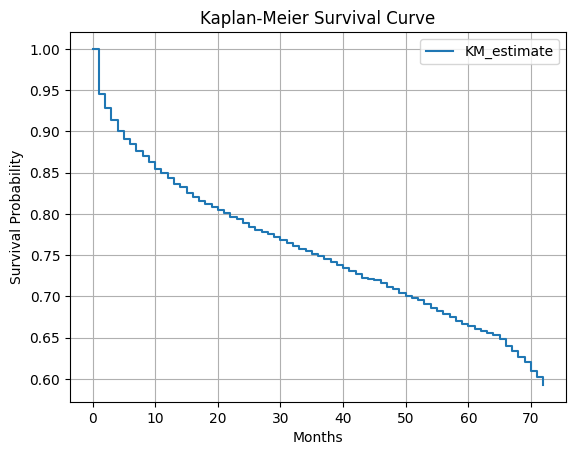

Median survival time is: inf months for entire dataset


In [ ]:
from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Initialize and fit the Kaplan-Meier estimator
kmf = KaplanMeierFitter()
kmf.fit(durations=df['tenure'], event_observed=df['Churn'])

# Add red "X" at the median
median_survival = kmf.median_survival_time_
plt.plot(median_survival, 0.5, 'rx', markersize=10, label='Median')

# Plotting the survival function
kmf.plot_survival_function(ci_show=False)
plt.title('Kaplan-Meier Survival Curve')
plt.xlabel('Months')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

print("Median survival time is:", median_survival, "months for entire dataset")

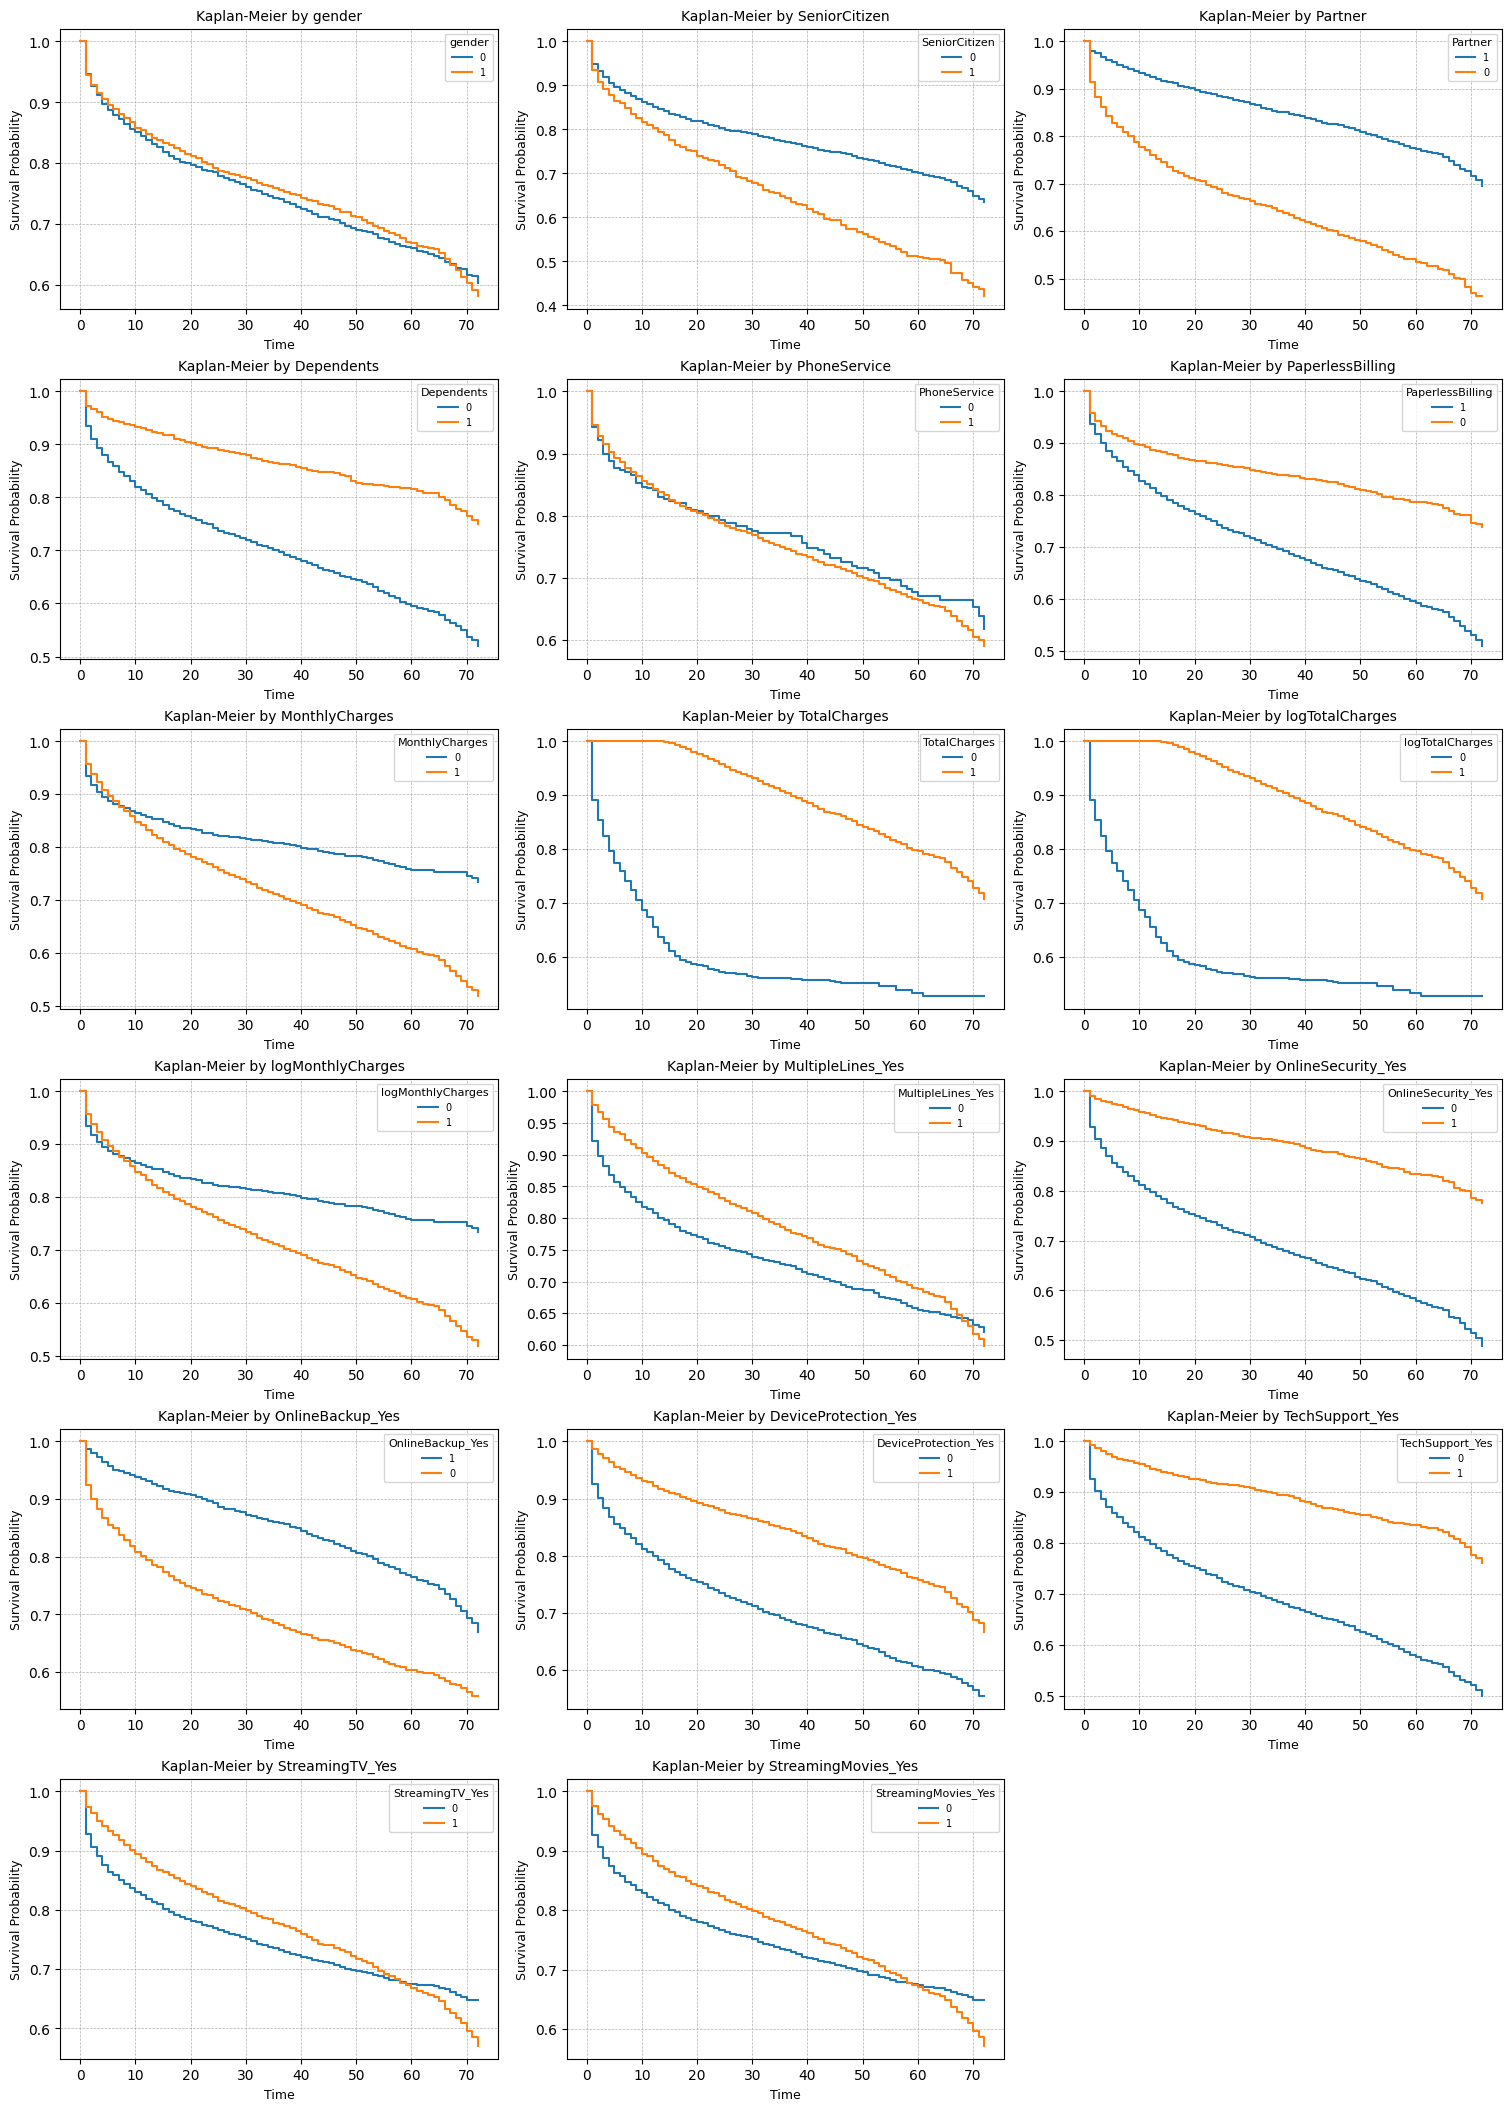

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
import math

def plot_kaplan_meier_subplots(df, duration_col, event_col, exclude_cols=None):
    kmf = KaplanMeierFitter()

    # Set default to empty list if None
    exclude_cols = exclude_cols or []

    # Exclude duration, event, and any user-specified columns
    categorical_columns = [
        col for col in df.columns
        if col not in [duration_col, event_col] + exclude_cols
        and df[col].nunique() <= 10  # Optional: limit to low-cardinality categorical variables
    ]

    n_cols = 3
    n_rows = math.ceil(len(categorical_columns) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), constrained_layout=True)
    axes = axes.flatten()

    for idx, col in enumerate(categorical_columns):
        ax = axes[idx]
        for value in df[col].dropna().unique():
            ix = df[col] == value
            kmf.fit(df.loc[ix, duration_col], df.loc[ix, event_col], label=str(value))
            kmf.plot_survival_function(ci_show=False, ax=ax, label=str(value))

        ax.set_title(f"Kaplan-Meier by {col}", fontsize=10)
        ax.set_xlabel("Time", fontsize=9)
        ax.set_ylabel("Survival Probability", fontsize=9)
        ax.legend(fontsize=7, title=col, title_fontsize=8)
        ax.grid(True, linestyle='--', linewidth=0.5)

    # Remove any unused subplots
    for i in range(len(categorical_columns), len(axes)):
        fig.delaxes(axes[i])

    plt.show()

exclude_columns = [
    'InternetService_DSL',
    'InternetService_Fiber optic',
    'Contract_One year',
    'Contract_Two year',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
]

plot_kaplan_meier_subplots(df, duration_col='tenure', event_col='Churn', exclude_cols=exclude_columns)

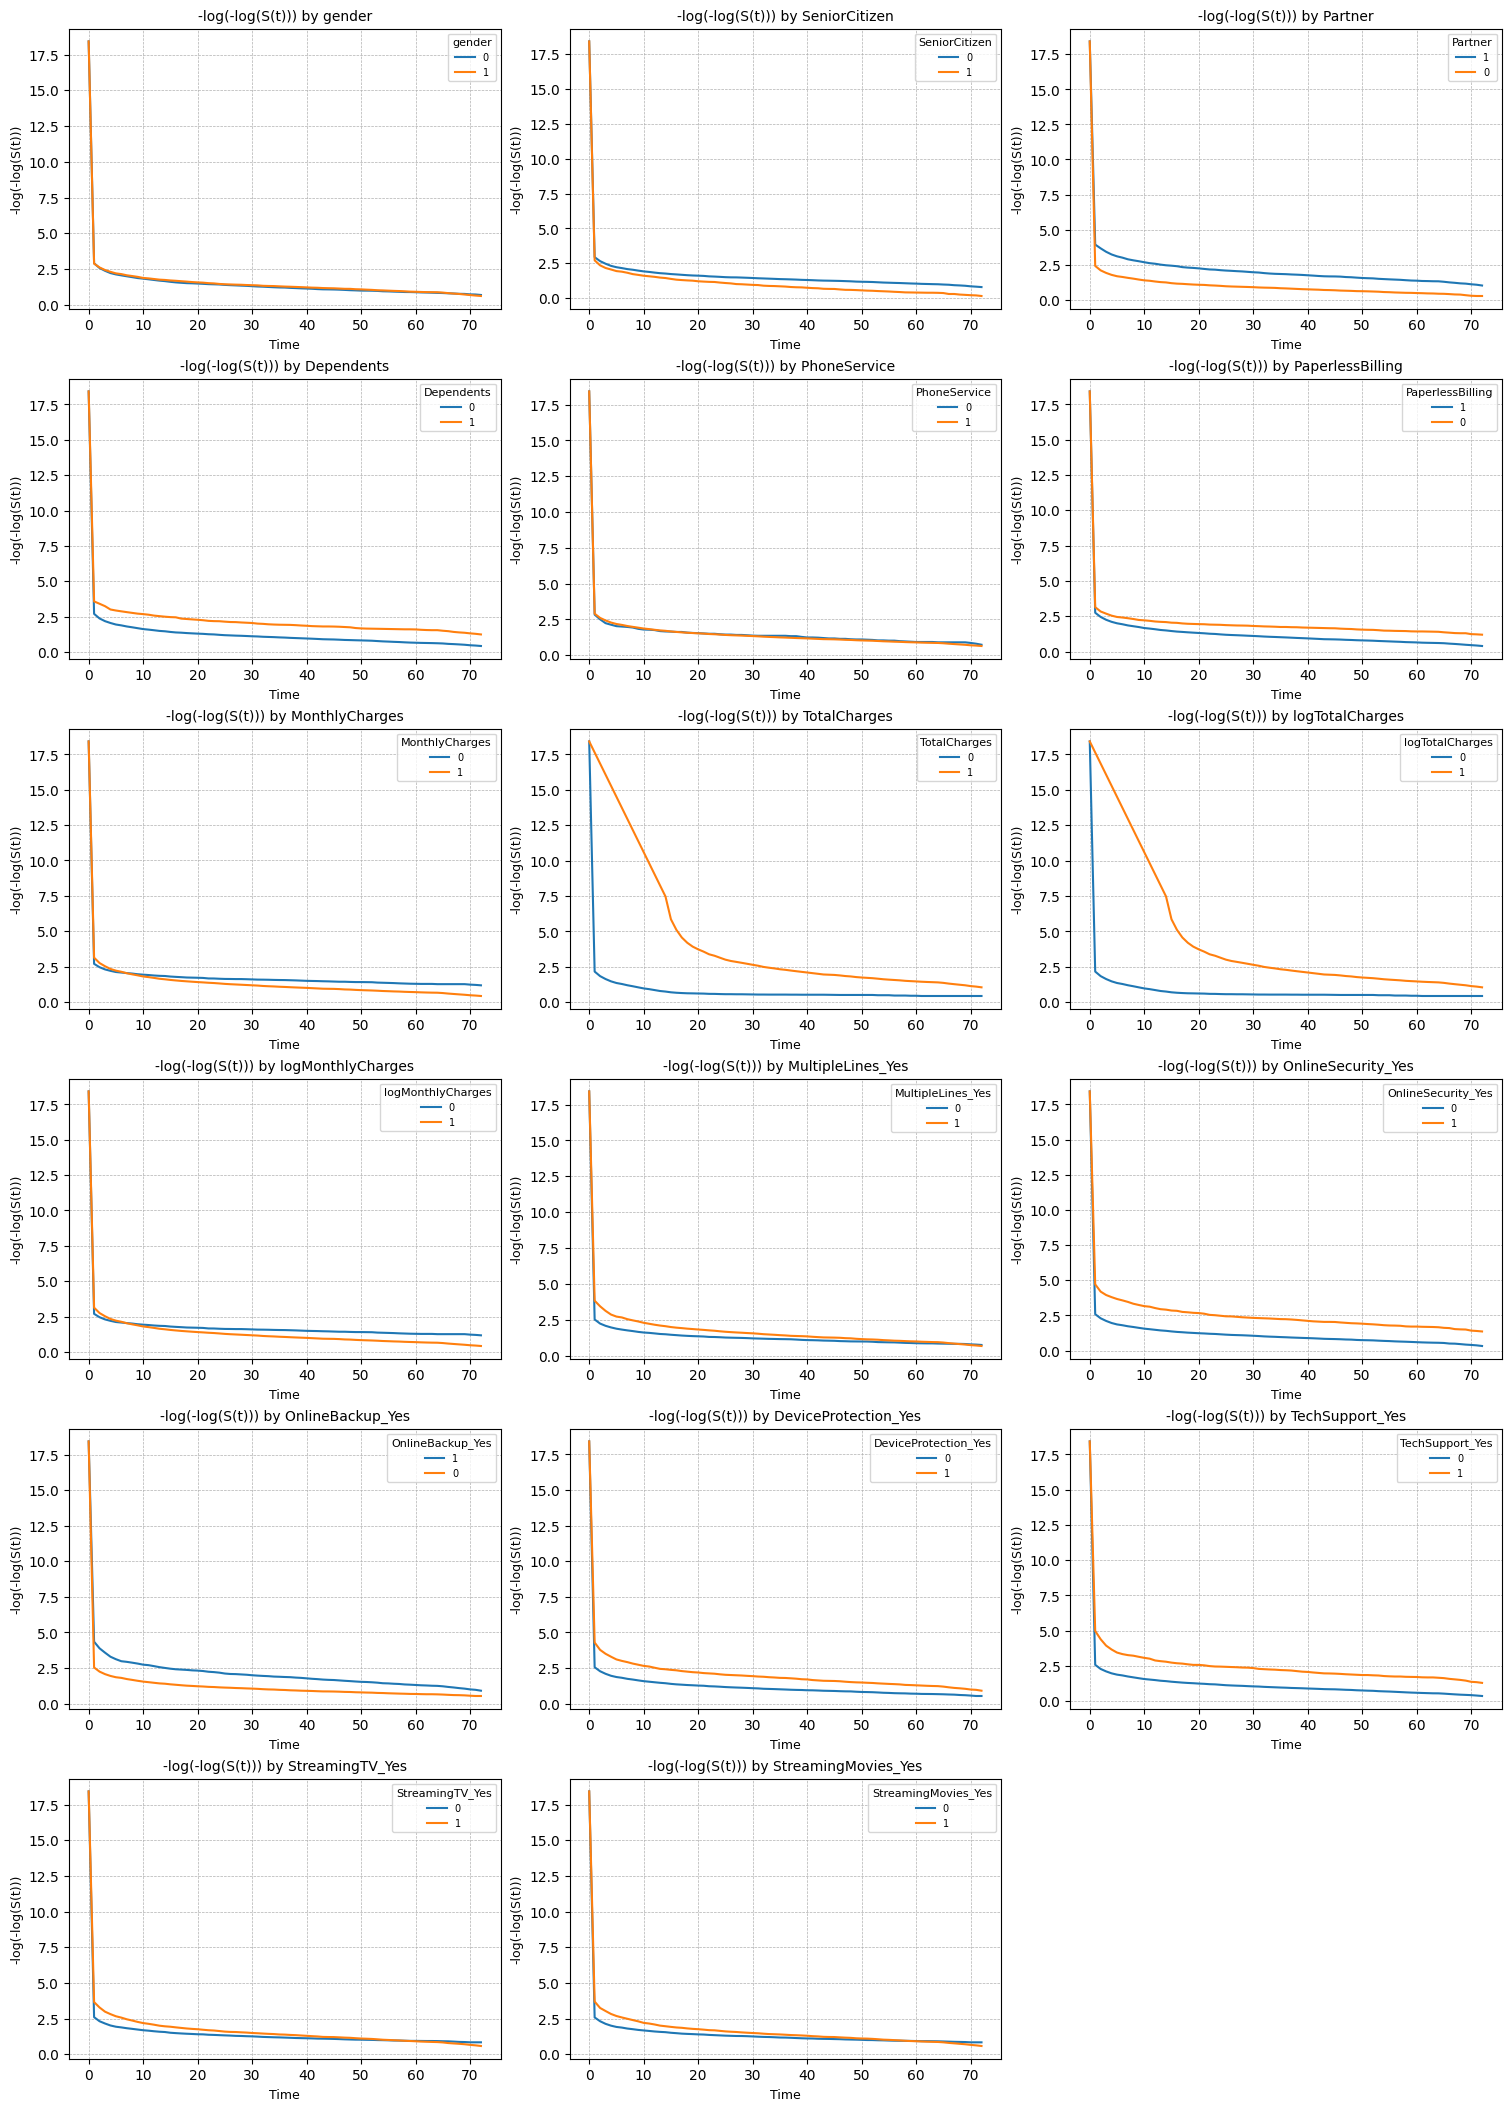

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lifelines import KaplanMeierFitter
import math

def plot_kaplan_meier_subplots(df, duration_col, event_col, exclude_cols=None):
    kmf = KaplanMeierFitter()

    exclude_cols = exclude_cols or []

    # Select low-cardinality categorical columns, excluding specified ones
    categorical_columns = [
        col for col in df.columns
        if col not in [duration_col, event_col] + exclude_cols
        and df[col].nunique() <= 10
    ]

    n_cols = 3
    n_rows = math.ceil(len(categorical_columns) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), constrained_layout=True)
    axes = axes.flatten()

    for idx, col in enumerate(categorical_columns):
        ax = axes[idx]
        for value in df[col].dropna().unique():
            ix = df[col] == value
            kmf.fit(df.loc[ix, duration_col], df.loc[ix, event_col], label=str(value))

            # Extract time and survival probabilities
            time = kmf.survival_function_.index.values
            S_t = kmf.survival_function_.iloc[:, 0].values

            # Clip S(t) to avoid log(0) or log of negative values
            S_t = np.clip(S_t, 1e-8, 1 - 1e-8)

            # Compute log(-log(S(t))) as log(log(1/S(t)))
            transformed = -np.log(-np.log(S_t))

            # Plot transformed survival function
            ax.plot(time, transformed, label=str(value))

        ax.set_title(f"-log(-log(S(t))) by {col}", fontsize=10)
        ax.set_xlabel("Time", fontsize=9)
        ax.set_ylabel("-log(-log(S(t)))", fontsize=9)
        ax.legend(fontsize=7, title=col, title_fontsize=8)
        ax.grid(True, linestyle='--', linewidth=0.5)

    # Remove any unused subplots
    for i in range(len(categorical_columns), len(axes)):
        fig.delaxes(axes[i])

    plt.show()

# Example usage
exclude_columns = [
    'InternetService_DSL',
    'InternetService_Fiber optic',
    'Contract_One year',
    'Contract_Two year',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
]

plot_kaplan_meier_subplots(df, duration_col='tenure', event_col='Churn', exclude_cols=exclude_columns)


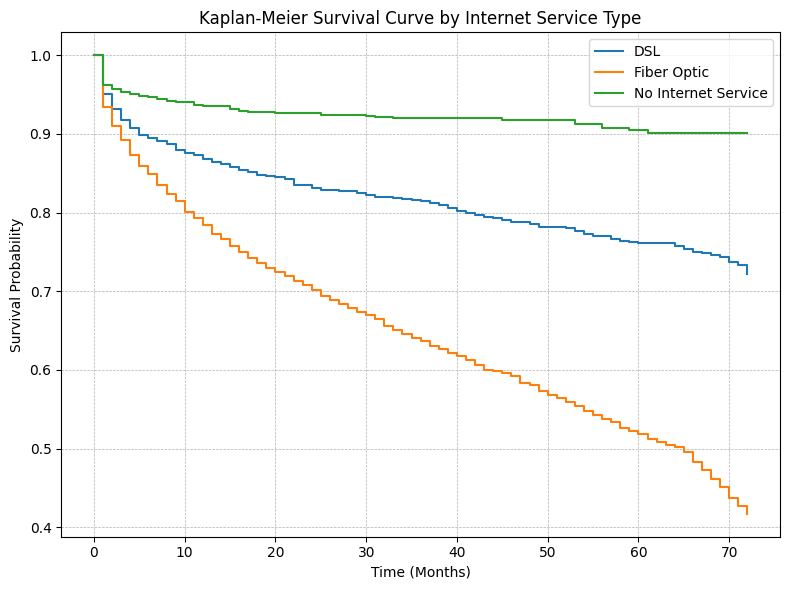

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

def plot_km_internet_service(df, duration_col, event_col):
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(8, 6))

    # Group 1: DSL
    dsl_mask = df['InternetService_DSL'] == 1
    kmf.fit(df.loc[dsl_mask, duration_col], df.loc[dsl_mask, event_col], label='DSL')
    kmf.plot_survival_function(ci_show=False)

    # Group 2: Fiber optic
    fiber_mask = df['InternetService_Fiber optic'] == 1
    kmf.fit(df.loc[fiber_mask, duration_col], df.loc[fiber_mask, event_col], label='Fiber Optic')
    kmf.plot_survival_function(ci_show=False)

    # Group 3: No internet service (both 0)
    no_internet_mask = (df['InternetService_DSL'] == 0) & (df['InternetService_Fiber optic'] == 0)
    kmf.fit(df.loc[no_internet_mask, duration_col], df.loc[no_internet_mask, event_col], label='No Internet Service')
    kmf.plot_survival_function(ci_show=False)

    # Final plot settings
    plt.title('Kaplan-Meier Survival Curve by Internet Service Type')
    plt.xlabel('Time (Months)')
    plt.ylabel('Survival Probability')
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Example usage
plot_km_internet_service(df, duration_col='tenure', event_col='Churn')

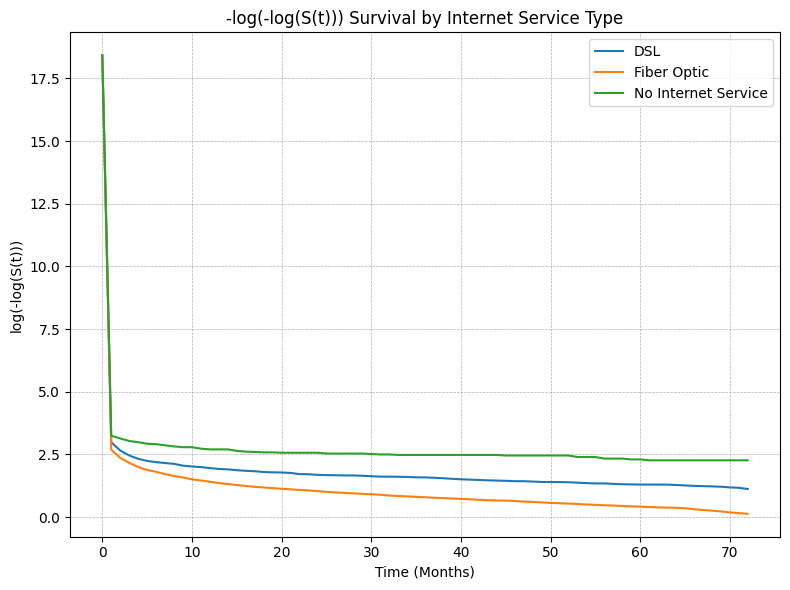

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import numpy as np

def plot_km_internet_service(df, duration_col, event_col):
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(8, 6))

    def plot_transformed(mask, label):
        kmf.fit(df.loc[mask, duration_col], df.loc[mask, event_col], label=label)
        time = kmf.survival_function_.index.values
        S_t = kmf.survival_function_.iloc[:, 0].values

        # Avoid log(0) by clipping values to small positive number
        S_t = np.clip(S_t, 1e-8, 1 - 1e-8)
        transformed = -np.log(-np.log(S_t))  # log(-log(S(t)))

        plt.plot(time, transformed, label=label)

    # Group 1: DSL
    dsl_mask = df['InternetService_DSL'] == 1
    plot_transformed(dsl_mask, 'DSL')

    # Group 2: Fiber optic
    fiber_mask = df['InternetService_Fiber optic'] == 1
    plot_transformed(fiber_mask, 'Fiber Optic')

    # Group 3: No internet service (both 0)
    no_internet_mask = (df['InternetService_DSL'] == 0) & (df['InternetService_Fiber optic'] == 0)
    plot_transformed(no_internet_mask, 'No Internet Service')

    # Final plot settings
    plt.title('-log(-log(S(t))) Survival by Internet Service Type')
    plt.xlabel('Time (Months)')
    plt.ylabel('log(-log(S(t)))')
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Example usage
plot_km_internet_service(df, duration_col='tenure', event_col='Churn')

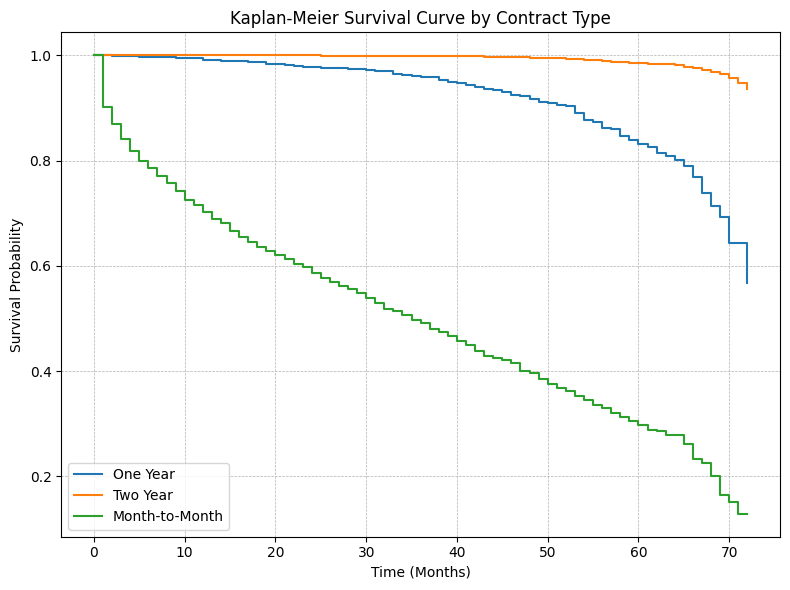

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

def plot_km_contract_types(df, duration_col, event_col):
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(8, 6))

    # Group 1: One year
    one_year = df['Contract_One year'] == 1
    kmf.fit(df.loc[one_year, duration_col], df.loc[one_year, event_col], label='One Year')
    kmf.plot_survival_function(ci_show=False)

    # Group 2: Two year
    two_year = df['Contract_Two year'] == 1
    kmf.fit(df.loc[two_year, duration_col], df.loc[two_year, event_col], label='Two Year')
    kmf.plot_survival_function(ci_show=False)

    # Group 3: Month-to-month (neither one_year nor two_year)
    month_to_month = (df['Contract_One year'] == 0) & (df['Contract_Two year'] == 0)
    kmf.fit(df.loc[month_to_month, duration_col], df.loc[month_to_month, event_col], label='Month-to-Month')
    kmf.plot_survival_function(ci_show=False)

    # Final plot settings
    plt.title('Kaplan-Meier Survival Curve by Contract Type')
    plt.xlabel('Time (Months)')
    plt.ylabel('Survival Probability')
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Example usage
plot_km_contract_types(df, duration_col='tenure', event_col='Churn')

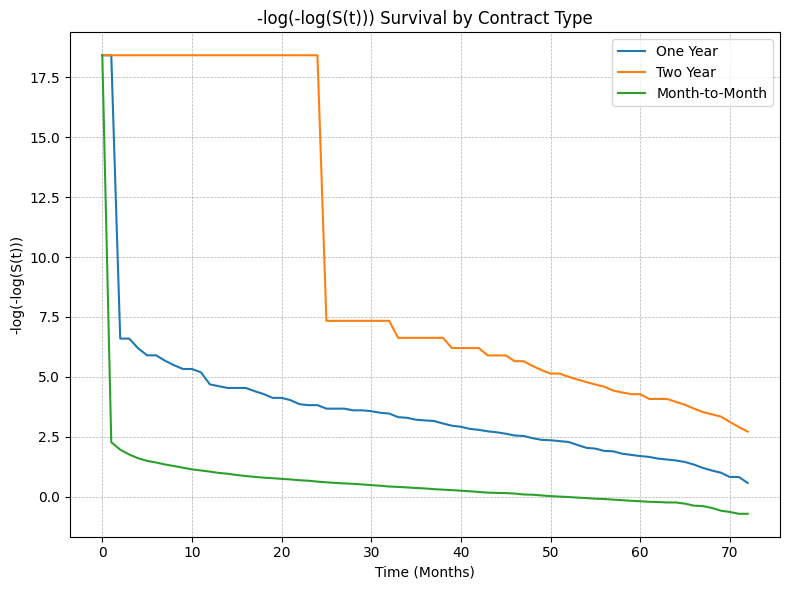

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import numpy as np

def plot_km_contract_types(df, duration_col, event_col):
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(8, 6))

    def plot_transformed(mask, label):
        kmf.fit(df.loc[mask, duration_col], df.loc[mask, event_col], label=label)
        time = kmf.survival_function_.index.values
        S_t = kmf.survival_function_.iloc[:, 0].values

        # Clip to avoid log(0)
        S_t = np.clip(S_t, 1e-8, 1 - 1e-8)
        transformed = -np.log(-np.log(S_t))  # log(-log(S(t)))

        plt.plot(time, transformed, label=label)

    # Group 1: One year
    one_year = df['Contract_One year'] == 1
    plot_transformed(one_year, 'One Year')

    # Group 2: Two year
    two_year = df['Contract_Two year'] == 1
    plot_transformed(two_year, 'Two Year')

    # Group 3: Month-to-month (both dummy vars are 0)
    month_to_month = (df['Contract_One year'] == 0) & (df['Contract_Two year'] == 0)
    plot_transformed(month_to_month, 'Month-to-Month')

    # Final plot settings
    plt.title('-log(-log(S(t))) Survival by Contract Type')
    plt.xlabel('Time (Months)')
    plt.ylabel('-log(-log(S(t)))')
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Example usage
plot_km_contract_types(df, duration_col='tenure', event_col='Churn')

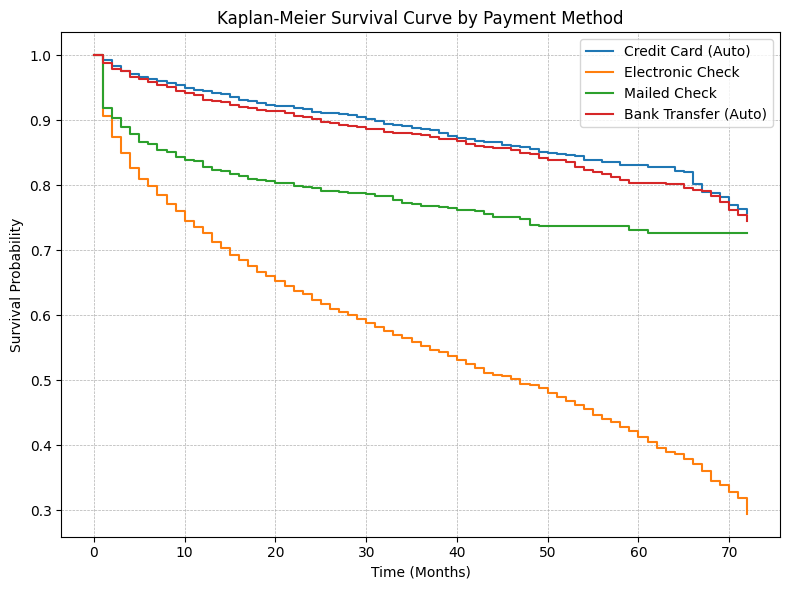

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

def plot_km_payment_methods(df, duration_col, event_col):
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(8, 6))

    # Group 1: Credit card (automatic)
    credit = df['PaymentMethod_Credit card (automatic)'] == 1
    kmf.fit(df.loc[credit, duration_col], df.loc[credit, event_col], label='Credit Card (Auto)')
    kmf.plot_survival_function(ci_show=False)

    # Group 2: Electronic check
    echeck = df['PaymentMethod_Electronic check'] == 1
    kmf.fit(df.loc[echeck, duration_col], df.loc[echeck, event_col], label='Electronic Check')
    kmf.plot_survival_function(ci_show=False)

    # Group 3: Mailed check
    mailed = df['PaymentMethod_Mailed check'] == 1
    kmf.fit(df.loc[mailed, duration_col], df.loc[mailed, event_col], label='Mailed Check')
    kmf.plot_survival_function(ci_show=False)

    # Group 4: Bank transfer (automatic) → all 0s in other methods
    bank_transfer = (
        (df['PaymentMethod_Credit card (automatic)'] == 0) &
        (df['PaymentMethod_Electronic check'] == 0) &
        (df['PaymentMethod_Mailed check'] == 0)
    )
    kmf.fit(df.loc[bank_transfer, duration_col], df.loc[bank_transfer, event_col], label='Bank Transfer (Auto)')
    kmf.plot_survival_function(ci_show=False)

    # Final plot settings
    plt.title('Kaplan-Meier Survival Curve by Payment Method')
    plt.xlabel('Time (Months)')
    plt.ylabel('Survival Probability')
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Example usage
plot_km_payment_methods(df, duration_col='tenure', event_col='Churn')

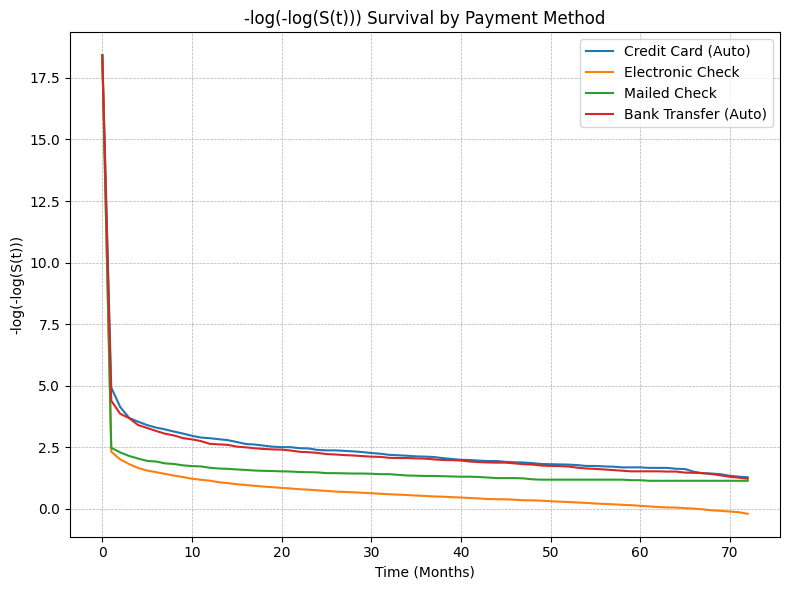

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import numpy as np

def plot_km_payment_methods(df, duration_col, event_col):
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(8, 6))

    def plot_transformed(mask, label):
        kmf.fit(df.loc[mask, duration_col], df.loc[mask, event_col], label=label)
        time = kmf.survival_function_.index.values
        S_t = kmf.survival_function_.iloc[:, 0].values

        # Clip to avoid log(0)
        S_t = np.clip(S_t, 1e-8, 1 - 1e-8)
        transformed = -np.log(-np.log(S_t))  # log(-log(S(t)))

        plt.plot(time, transformed, label=label)

    # Group 1: Credit card (automatic)
    credit = df['PaymentMethod_Credit card (automatic)'] == 1
    plot_transformed(credit, 'Credit Card (Auto)')

    # Group 2: Electronic check
    echeck = df['PaymentMethod_Electronic check'] == 1
    plot_transformed(echeck, 'Electronic Check')

    # Group 3: Mailed check
    mailed = df['PaymentMethod_Mailed check'] == 1
    plot_transformed(mailed, 'Mailed Check')

    # Group 4: Bank transfer (automatic) → all 0s in other methods
    bank_transfer = (
        (df['PaymentMethod_Credit card (automatic)'] == 0) &
        (df['PaymentMethod_Electronic check'] == 0) &
        (df['PaymentMethod_Mailed check'] == 0)
    )
    plot_transformed(bank_transfer, 'Bank Transfer (Auto)')

    # Final plot settings
    plt.title('-log(-log(S(t))) Survival by Payment Method')
    plt.xlabel('Time (Months)')
    plt.ylabel('-log(-log(S(t)))')
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Example usage
plot_km_payment_methods(df, duration_col='tenure', event_col='Churn')

In [ ]:
from lifelines import CoxPHFitter

selected_data = ['tenure','Churn','Partner','SeniorCitizen','Dependents','OnlineSecurity_Yes','DeviceProtection_Yes','PaperlessBilling','OnlineBackup_Yes','TechSupport_Yes','InternetService_Fiber optic','InternetService_DSL','Contract_One year','Contract_Two year','PaymentMethod_Credit card (automatic)','PaymentMethod_Electronic check','PaymentMethod_Mailed check']

# Initialize the Cox model
cph = CoxPHFitter()

# Fit the model
# Assuming 'duration' is the time column and 'event' is the event indicator (1 = event occurred, 0 = censored)
cph.fit(df[selected_data].dropna(), duration_col='tenure', event_col='Churn')

# Print summary
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -13929.45
         time fit was run = 2025-05-20 18:15:21 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
Partner                               -0.54      0.58      0.05           -0.65           -0.43                0.52                0.65
SeniorCitizen                         -0.12      0.89      0.06           -0.23           -0.01                0.79                0.99
Dependents                            -0.04      0.96      0.07           -0.17            0.09                0.84                1.10
OnlineSecurity_Yes                    -0.66      0.52      0.07           -0.78           -0.53                0.46                0.59
DeviceProtection_Yes                  -0.36      0.70      0.05           -0.47           -0.25                0.63                0.78
PaperlessBilling                       0.15      1.16      0.06            0.04            0.26                1.04                1.29
OnlineBackup_Yes                      -0.68      0.51      0.05           -0.78           -0.57                0.46                0.57
TechSupport_Yes                       -0.42      0.66      0.07           -0.55           -0.29                0.58                0.75
InternetService_Fiber optic            1.26      3.51      0.11            1.03            1.48                2.81                4.39
InternetService_DSL                    1.04      2.83      0.12            0.81            1.27                2.26                3.55
Contract_One year                     -1.64      0.19      0.09           -1.81           -1.47                0.16                0.23
Contract_Two year                     -3.29      0.04      0.16           -3.61           -2.97                0.03                0.05
PaymentMethod_Credit card (automatic) -0.07      0.94      0.09           -0.24            0.11                0.78                1.12
PaymentMethod_Electronic check         0.58      1.78      0.07            0.44            0.72                1.55                2.05
PaymentMethod_Mailed check             0.61      1.85      0.09            0.44            0.79                1.56                2.20

                                       cmp to      z      p  -log2(p)
covariate                                                            
Partner                                  0.00  -9.86 <0.005     73.80
SeniorCitizen                            0.00  -2.14   0.03      4.95
Dependents                               0.00  -0.58   0.57      0.82
OnlineSecurity_Yes                       0.00  -9.91 <0.005     74.47
DeviceProtection_Yes                     0.00  -6.71 <0.005     35.53
PaperlessBilling                         0.00   2.59   0.01      6.72
OnlineBackup_Yes                         0.00 -12.38 <0.005    114.53
TechSupport_Yes                          0.00  -6.44 <0.005     32.94
InternetService_Fiber optic              0.00  11.07 <0.005     92.26
InternetService_DSL                      0.00   9.02 <0.005     62.25
Contract_One year                        0.00 -18.68 <0.005    256.35
Contract_Two year                        0.00 -19.96 <0.005    292.05
PaymentMethod_Credit card (automatic)    0.00  -0.72   0.47      1.09
PaymentMethod_Electronic check           0.00   8.17 <0.005     51.53
PaymentMethod_Mailed check               0.00   6.98 <0.005     38.34
---
Concordance = 0.86
Partial AIC = 27888.89
log-likelihood ratio test = 3447.19 on 15 df
-log2(p) of ll-ratio test = inf

In [ ]:
# InternetService × OnlineSecurity
df['FiberOptic_x_Security'] = df['InternetService_Fiber optic'] * df['OnlineSecurity_Yes']

# InternetService × TechSupport
df['FiberOptic_x_TechSupport'] = df['InternetService_Fiber optic'] * df['TechSupport_Yes']

# SeniorCitizen × Services
df['Senior_x_TechSupport'] = df['SeniorCitizen'] * df['TechSupport_Yes']
df['Senior_x_DeviceProt'] = df['SeniorCitizen'] * df['DeviceProtection_Yes']

# PaymentMethod × PaperlessBilling
df['MailedCheck_x_Paperless'] = df['PaymentMethod_Mailed check'] * df['PaperlessBilling']

# Service bundle
df['DeviceProt_x_Backup'] = df['DeviceProtection_Yes'] * df['OnlineBackup_Yes']


interaction_cols = [
    'FiberOptic_x_Security',
    'FiberOptic_x_TechSupport',
    'Senior_x_TechSupport',
    'Senior_x_DeviceProt',
    'MailedCheck_x_Paperless',
    'DeviceProt_x_Backup']

In [ ]:
selected_data1 = ['tenure','Churn','Partner','SeniorCitizen','Dependents','OnlineSecurity_Yes','DeviceProtection_Yes','PaperlessBilling','OnlineBackup_Yes','TechSupport_Yes','InternetService_Fiber optic','InternetService_DSL','Contract_One year','Contract_Two year','PaymentMethod_Credit card (automatic)','PaymentMethod_Electronic check','PaymentMethod_Mailed check','FiberOptic_x_Security',
    'FiberOptic_x_TechSupport',
    'Senior_x_TechSupport',
    'Senior_x_DeviceProt',
    'MailedCheck_x_Paperless',
    'DeviceProt_x_Backup']

# Initialize the Cox model
cph1 = CoxPHFitter()

# Fit the model
# Assuming 'duration' is the time column and 'event' is the event indicator (1 = event occurred, 0 = censored)
cph1.fit(df[selected_data1].dropna(), duration_col='tenure', event_col='Churn')

# Print summary
cph1.print_summary()

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -13926.77
         time fit was run = 2025-05-20 18:15:22 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
Partner                               -0.54      0.58      0.05           -0.65           -0.43                0.52                0.65
SeniorCitizen                         -0.12      0.89      0.07           -0.26            0.02                0.77                1.02
Dependents                            -0.04      0.96      0.07           -0.17            0.10                0.84                1.10
OnlineSecurity_Yes                    -0.70      0.49      0.11           -0.92           -0.49                0.40                0.61
DeviceProtection_Yes                  -0.43      0.65      0.07           -0.57           -0.28                0.57                0.75
PaperlessBilling                       0.12      1.12      0.06           -0.01            0.24                0.99                1.27
OnlineBackup_Yes                      -0.75      0.47      0.07           -0.88           -0.62                0.41                0.54
TechSupport_Yes                       -0.48      0.62      0.11           -0.70           -0.27                0.50                0.77
InternetService_Fiber optic            1.25      3.50      0.11            1.03            1.48                2.79                4.38
InternetService_DSL                    1.08      2.94      0.12            0.84            1.31                2.32                3.72
Contract_One year                     -1.64      0.19      0.09           -1.81           -1.47                0.16                0.23
Contract_Two year                     -3.30      0.04      0.17           -3.63           -2.98                0.03                0.05
PaymentMethod_Credit card (automatic) -0.06      0.94      0.09           -0.24            0.12                0.79                1.13
PaymentMethod_Electronic check         0.58      1.79      0.07            0.45            0.72                1.56                2.06
PaymentMethod_Mailed check             0.54      1.71      0.12            0.30            0.77                1.35                2.16
FiberOptic_x_Security                  0.08      1.08      0.14           -0.19            0.34                0.83                1.41
FiberOptic_x_TechSupport               0.09      1.10      0.13           -0.17            0.36                0.84                1.43
Senior_x_TechSupport                   0.03      1.03      0.17           -0.29            0.36                0.75                1.43
Senior_x_DeviceProt                   -0.01      0.99      0.12           -0.24            0.22                0.79                1.25
MailedCheck_x_Paperless                0.13      1.14      0.13           -0.12            0.39                0.88                1.48
DeviceProt_x_Backup                    0.21      1.23      0.11           -0.01            0.42                0.99                1.53

                                       cmp to      z      p  -log2(p)
covariate                                                            
Partner                                  0.00  -9.86 <0.005     73.70
SeniorCitizen                            0.00  -1.74   0.08      3.61
Dependents                               0.00  -0.54   0.59      0.76
OnlineSecurity_Yes                       0.00  -6.38 <0.005     32.38
DeviceProtection_Yes                     0.00  -5.87 <0.005     27.75
PaperlessBilling

In [ ]:
from lifelines import CoxPHFitter
from scipy.stats import chi2

# Fit the reduced model (without interaction terms)
reduced_data = selected_data

cph_reduced = CoxPHFitter()
cph_reduced.fit(df[reduced_data].dropna(), duration_col='tenure', event_col='Churn')

# Fit the full model (with interaction terms)
full_data = reduced_data + interaction_cols

cph_full = CoxPHFitter()
cph_full.fit(df[full_data].dropna(), duration_col='tenure', event_col='Churn')

# Calculate the log-likelihoods of both models
log_likelihood_reduced = cph_reduced.log_likelihood_
log_likelihood_full = cph_full.log_likelihood_

# Compute the LR statistic
lr_statistic = -2 * (log_likelihood_reduced - log_likelihood_full)

# Degrees of freedom is the number of interaction terms added
df_interactions = len(full_data) - len(reduced_data)

# Compute the p-value for the LR statistic using the chi-square distribution
p_value = chi2.sf(lr_statistic, df_interactions)

# Print the result
print(f"Likelihood Ratio Statistic: {lr_statistic}")
print(f"P-value: {p_value}")

# Conclusion: If p-value < 0.05, the interaction terms are significant
if p_value < 0.05:
    print("The interaction terms significantly improve the model fit.")
else:
    print("The interaction terms do not significantly improve the model fit.")


Likelihood Ratio Statistic: 5.351431001839956
P-value: 0.4995919257146205
The interaction terms do not significantly improve the model fit.


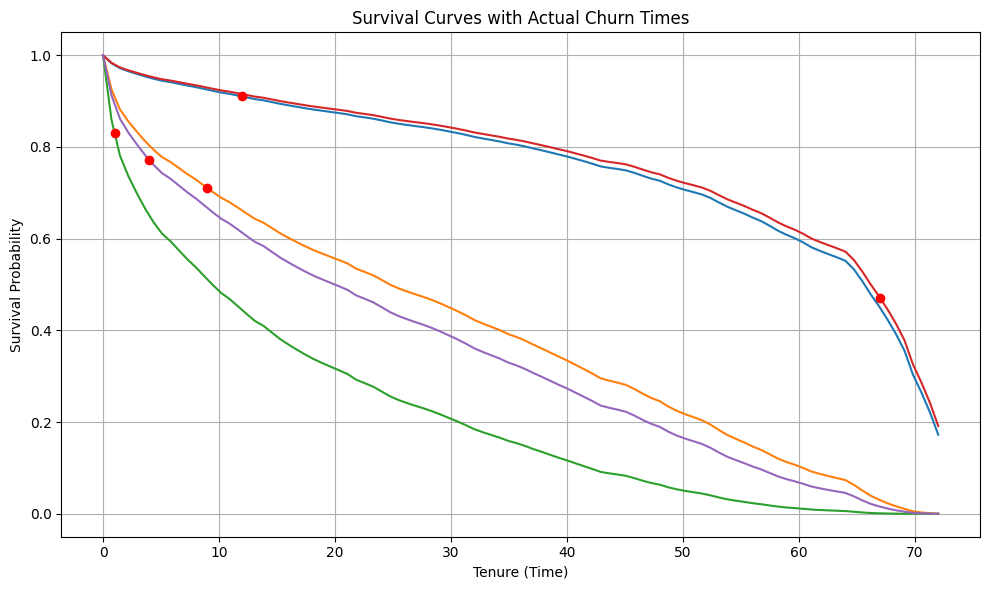

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Select the last 5 observations where Churn = 1
last_5_churn = df[df['Churn'] == 1].tail(5)

# Step 2: Create a time grid
time_grid = np.linspace(0, df['tenure'].max(), 100)

# Step 3: Predict survival functions for these 5 observations
surv_funcs = cph.predict_survival_function(last_5_churn, times=time_grid)

# Step 4: Plot survival curves and actual failure points
plt.figure(figsize=(10, 6))

for i, index in enumerate(last_5_churn.index):
    # Plot the survival curve
    plt.plot(time_grid, surv_funcs.iloc[:, i], label=f"Obs {i+1}")

    # Get actual tenure (event time)
    tenure_time = last_5_churn.loc[index, 'tenure']

    # Get predicted survival probability at actual tenure
    # Use interpolation since tenure may not exactly match a time_grid point
    survival_prob = np.interp(tenure_time, time_grid, surv_funcs.iloc[:, i])

    # Plot the red dot on the curve at (tenure, survival_prob)
    plt.scatter(tenure_time, survival_prob, color='red', zorder=5)

# Step 5: Final plot styling
plt.title('Survival Curves with Actual Churn Times')
plt.xlabel('Tenure (Time)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Step 1: Select churned customers
churned_df = df[df['Churn'] == 1].copy()

# Step 2: Create a time grid for interpolation
time_grid = np.linspace(0, df['tenure'].max(), 100)

# Step 3: For each churned observation, compute the survival curve and median survival time
differences = []

for idx in churned_df.index:
    obs = churned_df.loc[[idx]]  # Keep it as a DataFrame for prediction
    surv_func = cph.predict_survival_function(obs, times=time_grid)
    survival_probs = surv_func.iloc[:, 0].values

    # Find the time where survival drops below 0.5 (i.e., median survival time)
    median_index = np.where(survival_probs <= 0.5)[0]
    if len(median_index) > 0:
        median_surv_time = time_grid[median_index[0]]
    else:
        median_surv_time = time_grid[-1]  # Right-censored at max time

    actual_tenure = obs['tenure'].values[0]
    difference = actual_tenure - median_surv_time
    differences.append(difference)

# Step 4: Calculate the average difference
avg_difference = np.mean(differences)
print(f"Average difference (tenure - predicted median survival time): {avg_difference:.2f}")

Average difference (tenure - predicted median survival time): -16.62


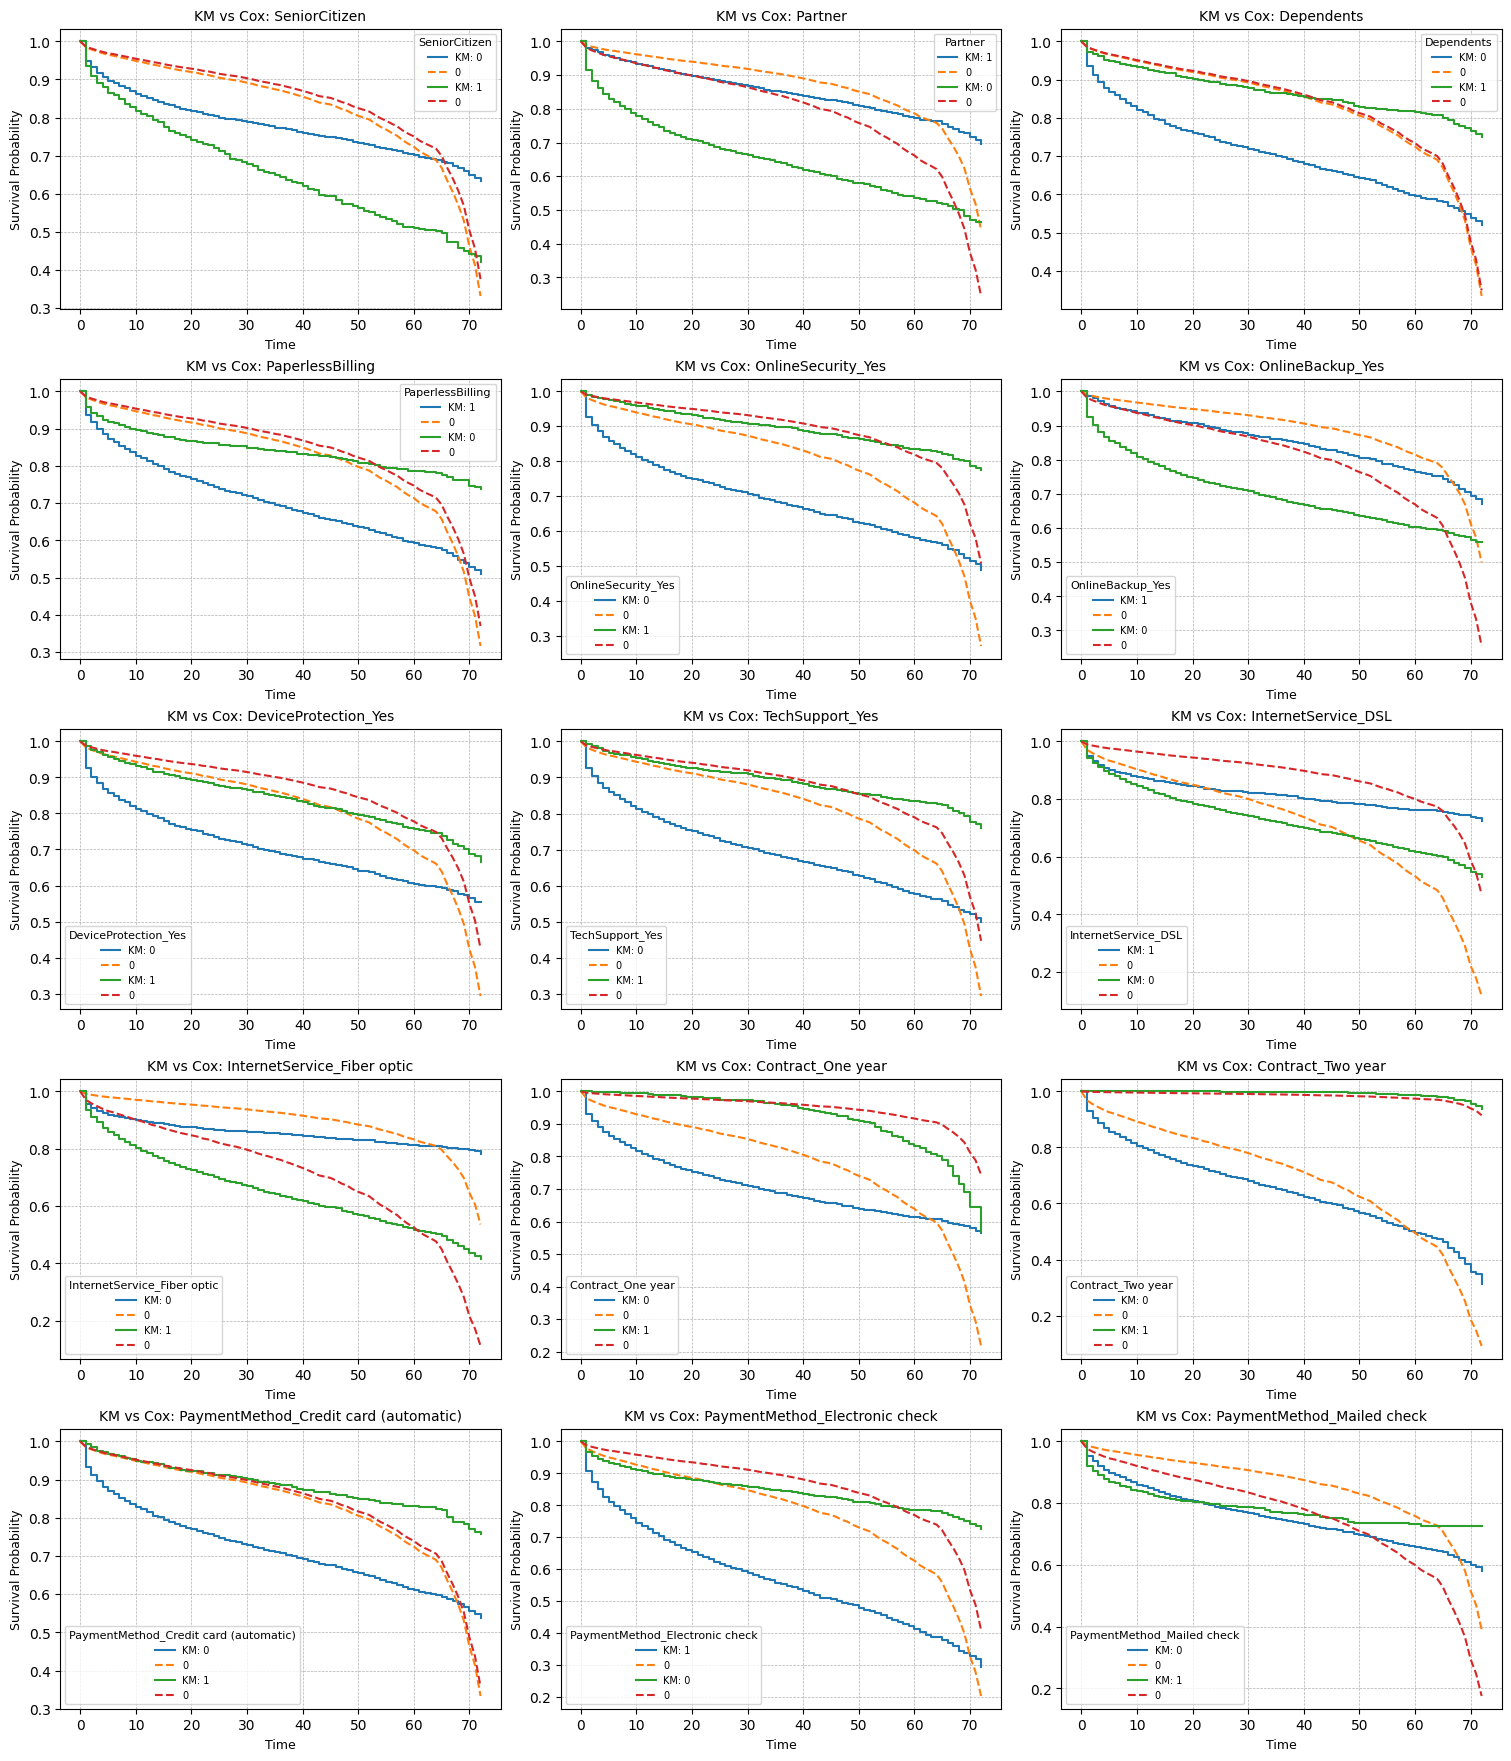

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
import math

def plot_km_vs_cox_subplots(df, cph_model, duration_col, event_col, exclude_cols=None):
    kmf = KaplanMeierFitter()
    exclude_cols = exclude_cols or []

    # Only include categorical covariates that were used in the Cox model
    model_vars = set(cph_model.params_.index)
    categorical_columns = [
        col for col in df.columns
        if col in model_vars  # only if in Cox model
        and col not in [duration_col, event_col] + exclude_cols
        and df[col].nunique() <= 10
    ]

    n_cols = 3
    n_rows = math.ceil(len(categorical_columns) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), constrained_layout=True)
    axes = axes.flatten()

    for idx, col in enumerate(categorical_columns):
        ax = axes[idx]
        values = df[col].dropna().unique()

        for value in values:
            mask = df[col] == value

            # Kaplan-Meier (Observed)
            kmf.fit(df.loc[mask, duration_col], df.loc[mask, event_col], label=f"KM: {value}")
            kmf.plot_survival_function(ax=ax, ci_show=False)

            # Cox PH (Expected)
            mean_covariates = df[cph_model.params_.index].mean()
            mean_covariates[col] = value
            survival_curve = cph_model.predict_survival_function(mean_covariates.to_frame().T)
            survival_curve.plot(ax=ax, linestyle='--', label=f"Cox: {value}")

        ax.set_title(f"KM vs Cox: {col}", fontsize=10)
        ax.set_xlabel("Time", fontsize=9)
        ax.set_ylabel("Survival Probability", fontsize=9)
        ax.legend(fontsize=7, title=col, title_fontsize=8)
        ax.grid(True, linestyle='--', linewidth=0.5)

    for i in range(len(categorical_columns), len(axes)):
        fig.delaxes(axes[i])

    plt.show()


selected_data = [
    'tenure','Churn','Partner','SeniorCitizen','Dependents','OnlineSecurity_Yes',
    'DeviceProtection_Yes','PaperlessBilling','OnlineBackup_Yes','TechSupport_Yes',
    'InternetService_Fiber optic','InternetService_DSL','Contract_One year',
    'Contract_Two year','PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check','PaymentMethod_Mailed check'
]

cph = CoxPHFitter()
cph.fit(df[selected_data].dropna(), duration_col='tenure', event_col='Churn')

# Plot only variables in the model
plot_km_vs_cox_subplots(df.dropna(subset=selected_data), cph_model=cph, duration_col='tenure', event_col='Churn')


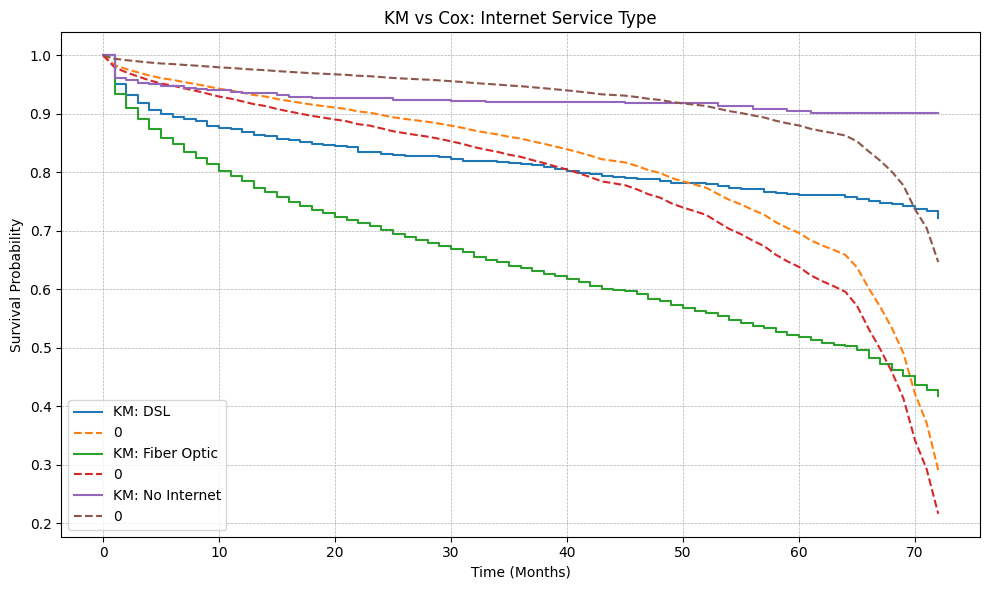

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

def plot_km_vs_cox_internet_service(df, cph_model, duration_col='tenure', event_col='Churn'):
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(10, 6))

    ax = plt.gca()

    # Prepare a baseline covariate profile (mean values of features)
    base_cov = df[cph_model.params_.index].mean()

    # ----- DSL -----
    dsl_mask = df['InternetService_DSL'] == 1
    kmf.fit(df.loc[dsl_mask, duration_col], df.loc[dsl_mask, event_col], label='KM: DSL')
    kmf.plot_survival_function(ci_show=False, ax=ax)

    cov_dsl = base_cov.copy()
    cov_dsl['InternetService_DSL'] = 1
    cov_dsl['InternetService_Fiber optic'] = 0
    surv_dsl = cph_model.predict_survival_function(cov_dsl.to_frame().T)
    surv_dsl.plot(ax=ax, linestyle='--', label='Cox: DSL')

    # ----- Fiber Optic -----
    fiber_mask = df['InternetService_Fiber optic'] == 1
    kmf.fit(df.loc[fiber_mask, duration_col], df.loc[fiber_mask, event_col], label='KM: Fiber Optic')
    kmf.plot_survival_function(ci_show=False, ax=ax)

    cov_fiber = base_cov.copy()
    cov_fiber['InternetService_DSL'] = 0
    cov_fiber['InternetService_Fiber optic'] = 1
    surv_fiber = cph_model.predict_survival_function(cov_fiber.to_frame().T)
    surv_fiber.plot(ax=ax, linestyle='--', label='Cox: Fiber Optic')

    # ----- No Internet -----
    no_internet_mask = (df['InternetService_DSL'] == 0) & (df['InternetService_Fiber optic'] == 0)
    kmf.fit(df.loc[no_internet_mask, duration_col], df.loc[no_internet_mask, event_col], label='KM: No Internet')
    kmf.plot_survival_function(ci_show=False, ax=ax)

    cov_none = base_cov.copy()
    cov_none['InternetService_DSL'] = 0
    cov_none['InternetService_Fiber optic'] = 0
    surv_none = cph_model.predict_survival_function(cov_none.to_frame().T)
    surv_none.plot(ax=ax, linestyle='--', label='Cox: No Internet')

    # Final plot settings
    plt.title('KM vs Cox: Internet Service Type')
    plt.xlabel('Time (Months)')
    plt.ylabel('Survival Probability')
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Ensure Cox model is fit
cph.fit(df[selected_data].dropna(), duration_col='tenure', event_col='Churn')

# Generate combined plot
plot_km_vs_cox_internet_service(df.dropna(subset=selected_data), cph)

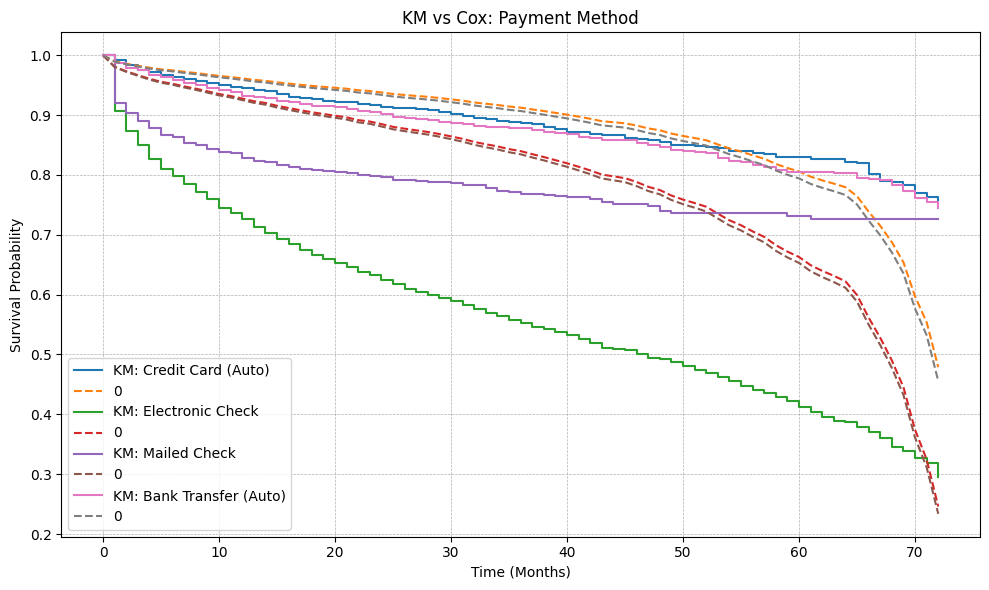

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

def plot_km_vs_cox_payment_methods(df, cph_model, duration_col='tenure', event_col='Churn'):
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(10, 6))
    ax = plt.gca()

    # Baseline covariates for Cox predictions
    base_cov = df[cph_model.params_.index].mean()

    # ----- 1. Credit Card (Auto) -----
    credit = df['PaymentMethod_Credit card (automatic)'] == 1
    kmf.fit(df.loc[credit, duration_col], df.loc[credit, event_col], label='KM: Credit Card (Auto)')
    kmf.plot_survival_function(ci_show=False, ax=ax)

    cov_credit = base_cov.copy()
    cov_credit['PaymentMethod_Credit card (automatic)'] = 1
    cov_credit['PaymentMethod_Electronic check'] = 0
    cov_credit['PaymentMethod_Mailed check'] = 0
    cph_model.predict_survival_function(cov_credit.to_frame().T).plot(ax=ax, linestyle='--', label='Cox: Credit Card (Auto)')

    # ----- 2. Electronic Check -----
    echeck = df['PaymentMethod_Electronic check'] == 1
    kmf.fit(df.loc[echeck, duration_col], df.loc[echeck, event_col], label='KM: Electronic Check')
    kmf.plot_survival_function(ci_show=False, ax=ax)

    cov_echeck = base_cov.copy()
    cov_echeck['PaymentMethod_Credit card (automatic)'] = 0
    cov_echeck['PaymentMethod_Electronic check'] = 1
    cov_echeck['PaymentMethod_Mailed check'] = 0
    cph_model.predict_survival_function(cov_echeck.to_frame().T).plot(ax=ax, linestyle='--', label='Cox: Electronic Check')

    # ----- 3. Mailed Check -----
    mailed = df['PaymentMethod_Mailed check'] == 1
    kmf.fit(df.loc[mailed, duration_col], df.loc[mailed, event_col], label='KM: Mailed Check')
    kmf.plot_survival_function(ci_show=False, ax=ax)

    cov_mailed = base_cov.copy()
    cov_mailed['PaymentMethod_Credit card (automatic)'] = 0
    cov_mailed['PaymentMethod_Electronic check'] = 0
    cov_mailed['PaymentMethod_Mailed check'] = 1
    cph_model.predict_survival_function(cov_mailed.to_frame().T).plot(ax=ax, linestyle='--', label='Cox: Mailed Check')

    # ----- 4. Bank Transfer (Auto) [Reference Category] -----
    bank_transfer = (
        (df['PaymentMethod_Credit card (automatic)'] == 0) &
        (df['PaymentMethod_Electronic check'] == 0) &
        (df['PaymentMethod_Mailed check'] == 0)
    )
    kmf.fit(df.loc[bank_transfer, duration_col], df.loc[bank_transfer, event_col], label='KM: Bank Transfer (Auto)')
    kmf.plot_survival_function(ci_show=False, ax=ax)

    cov_bank = base_cov.copy()
    cov_bank['PaymentMethod_Credit card (automatic)'] = 0
    cov_bank['PaymentMethod_Electronic check'] = 0
    cov_bank['PaymentMethod_Mailed check'] = 0
    cph_model.predict_survival_function(cov_bank.to_frame().T).plot(ax=ax, linestyle='--', label='Cox: Bank Transfer (Auto)')

    # Final plot settings
    plt.title('KM vs Cox: Payment Method')
    plt.xlabel('Time (Months)')
    plt.ylabel('Survival Probability')
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()


# Fit Cox model first if needed
cph.fit(df[selected_data].dropna(), duration_col='tenure', event_col='Churn')

# Then call the plot
plot_km_vs_cox_payment_methods(df.dropna(subset=selected_data), cph)

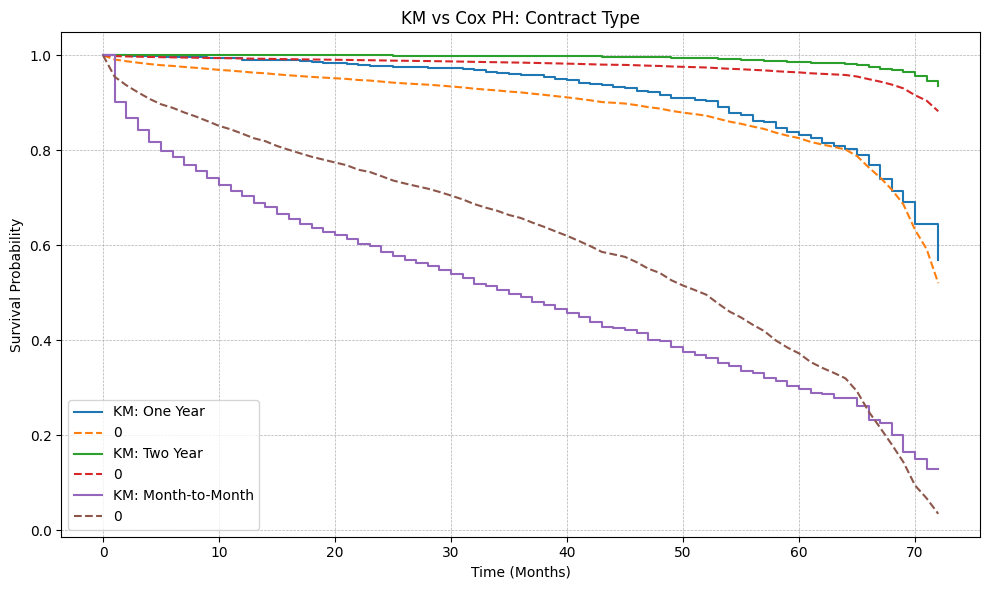

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

def plot_km_vs_cox_contract_types(df, cph_model, duration_col='tenure', event_col='Churn'):
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(10, 6))
    ax = plt.gca()

    # Baseline covariates for Cox predictions
    base_cov = df[cph_model.params_.index].mean()

    # ----- One Year Contract -----
    one_year = df['Contract_One year'] == 1
    kmf.fit(df.loc[one_year, duration_col], df.loc[one_year, event_col], label='KM: One Year')
    kmf.plot_survival_function(ci_show=False, ax=ax)

    cov_one = base_cov.copy()
    cov_one['Contract_One year'] = 1
    cov_one['Contract_Two year'] = 0
    cph_model.predict_survival_function(cov_one.to_frame().T).plot(ax=ax, linestyle='--', label='Cox: One Year')

    # ----- Two Year Contract -----
    two_year = df['Contract_Two year'] == 1
    kmf.fit(df.loc[two_year, duration_col], df.loc[two_year, event_col], label='KM: Two Year')
    kmf.plot_survival_function(ci_show=False, ax=ax)

    cov_two = base_cov.copy()
    cov_two['Contract_One year'] = 0
    cov_two['Contract_Two year'] = 1
    cph_model.predict_survival_function(cov_two.to_frame().T).plot(ax=ax, linestyle='--', label='Cox: Two Year')

    # ----- Month-to-Month (Reference) -----
    month_to_month = (df['Contract_One year'] == 0) & (df['Contract_Two year'] == 0)
    kmf.fit(df.loc[month_to_month, duration_col], df.loc[month_to_month, event_col], label='KM: Month-to-Month')
    kmf.plot_survival_function(ci_show=False, ax=ax)

    cov_month = base_cov.copy()
    cov_month['Contract_One year'] = 0
    cov_month['Contract_Two year'] = 0
    cph_model.predict_survival_function(cov_month.to_frame().T).plot(ax=ax, linestyle='--', label='Cox: Month-to-Month')

    # Final plot settings
    plt.title('KM vs Cox PH: Contract Type')
    plt.xlabel('Time (Months)')
    plt.ylabel('Survival Probability')
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Ensure Cox model is fit
cph.fit(df[selected_data].dropna(), duration_col='tenure', event_col='Churn')

# Then plot
plot_km_vs_cox_contract_types(df.dropna(subset=selected_data), cph)